In [2]:
import numpy as np
from scipy.signal import hilbert
from joblib import Parallel, delayed
import os
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import Sleep_Scripts.feature_visualizations as F
import matplotlib.pyplot as plt

import pandas as pd


In [3]:
# Rodent Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,5]
# theta_band = [6,10]
sigma_band = [11,17]
# beta_band = [22,30]
gamma_band = [8,12]
total_band = [0,30]

In [4]:
# Human frequency bands (AASM)
# noise_band = [0,0.49]
# delta_band = [0.5,3.99]
theta_band = [4,8]
alpha_band = [8,12]
# sigma_band = [12,15.99]
beta_band = [16,30]
# gamma_band = [30,40]
# total_band = [0,40]

### Functions

In [5]:
def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

In [6]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [7]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

### Establish parameters

In [8]:
subject = "2"
night = "1"
file_type = "converted_uni_and_bi"
# Channel to use for retrieving HPC bands
hpc_channel = 'TR10'
# Channel to use for retrieving PFC bands
pfc_channel = "TL01"
os.makedirs(os.path.join("D:/EEG_Data_stage","plots", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("D:/EEG_Data_stage","plots", file_type, subject, f"night{night}")


In [9]:
fs = 250
epoch_length = 10 
window_length = epoch_length * fs

### Load data

In [10]:
files, scores_files = fragment_join(subject, night, file_type)
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband ed

In [11]:
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

In [12]:
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
EMG = abs(hilbert(EMG))

### Artefact zeroing

In [13]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)[0]
raw_pfc = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)[0]

In [14]:
sleep_scoring = np.ravel(states)
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [15]:
### Get EOG
EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])

In [16]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs

### Multicore power band calculation

In [17]:
raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [18]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

### Plots


In [19]:
# Index calculations
index_n = F.index_N(delta_norm, alpha_norm, EMG_norm, EOG1, EOG2, epoch_length, fs)

index_r = F.index_R(delta_norm, sigma_norm, EMG_norm, EOG1, EOG2, epoch_length, fs)

index_w = F.index_W(theta_norm, gamma_norm, EMG_norm)


1
Problematic windows: 3
First 10 problematic windows: [(561, 'flat_or_empty'), (1496, 'flat_or_empty'), (1497, 'flat_or_empty')]


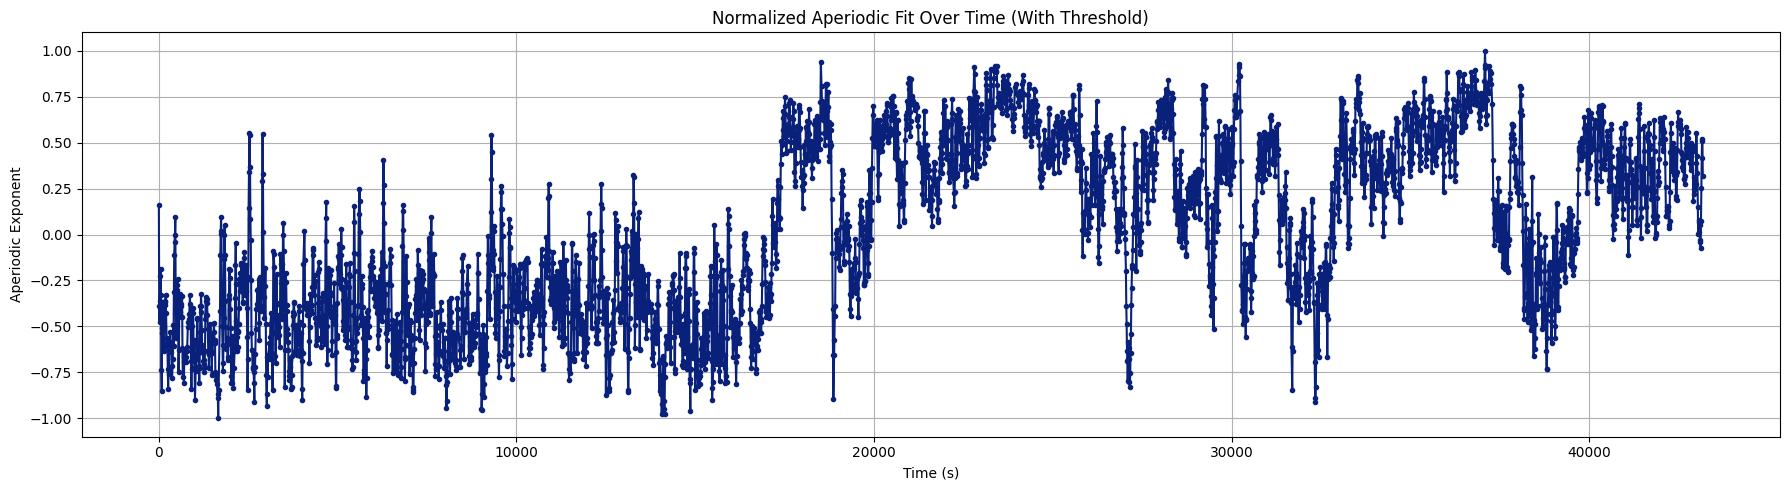

New data shape: (4318, 2500)


C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\timmi\miniconda3\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\U

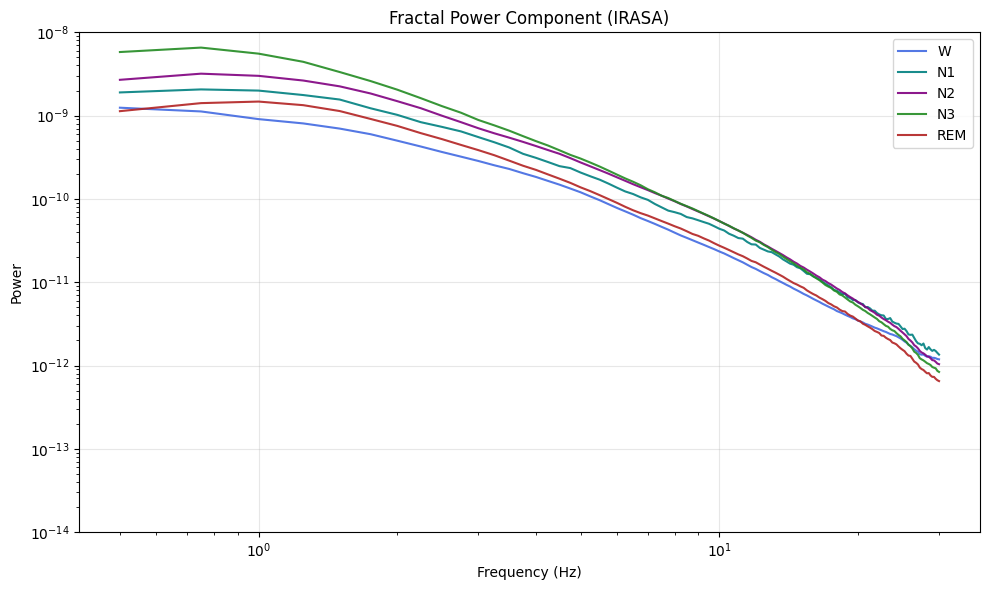

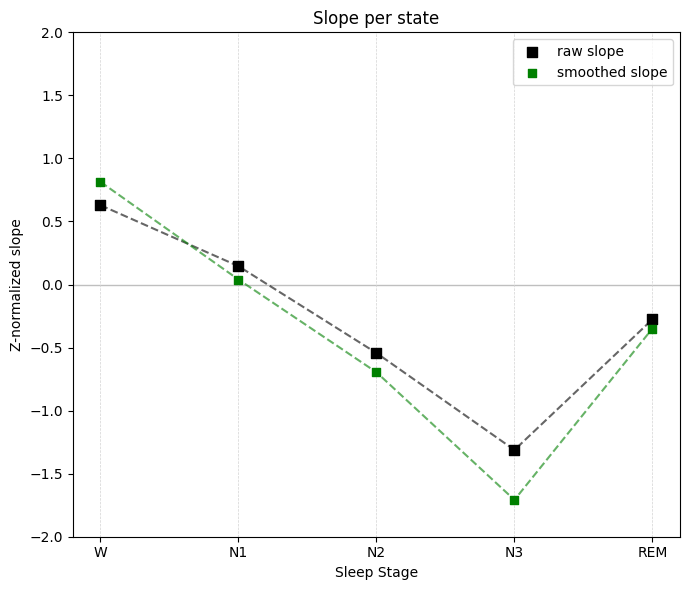

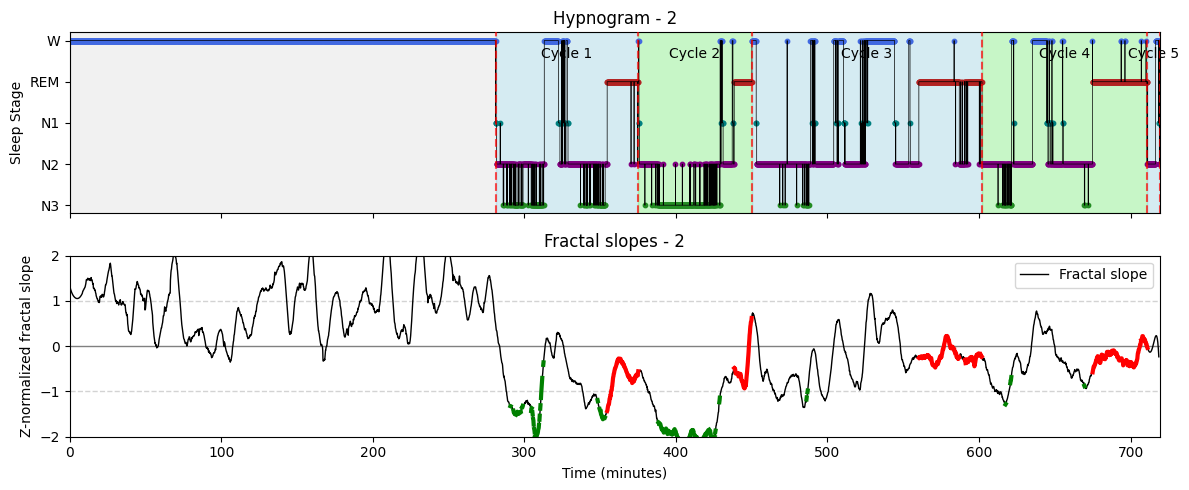

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 50 Hz                        
                                 Frequency Resolution is 0.24 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -6.9512, 3.8237                                          
                                                                                                  
                                       3 peaks were found:                                        
          

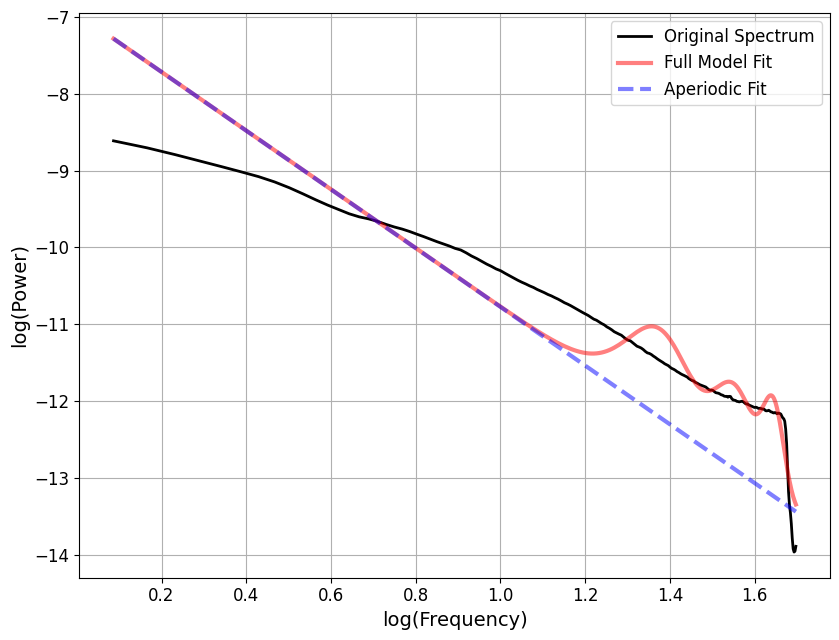

   state      mean       sem
0      0 -0.375427  0.006179
1      1 -0.192050  0.034140
2      2  0.363661  0.008724
3      3  0.615009  0.008895
4      4  0.386041  0.007236


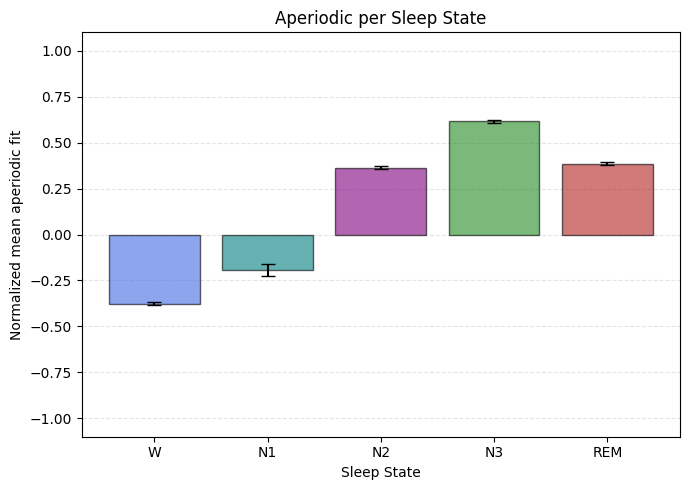

Counts per state (0..4): [1954, 63, 1200, 307, 620]
Unique states present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:1042: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:1042: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(
C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:1066: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


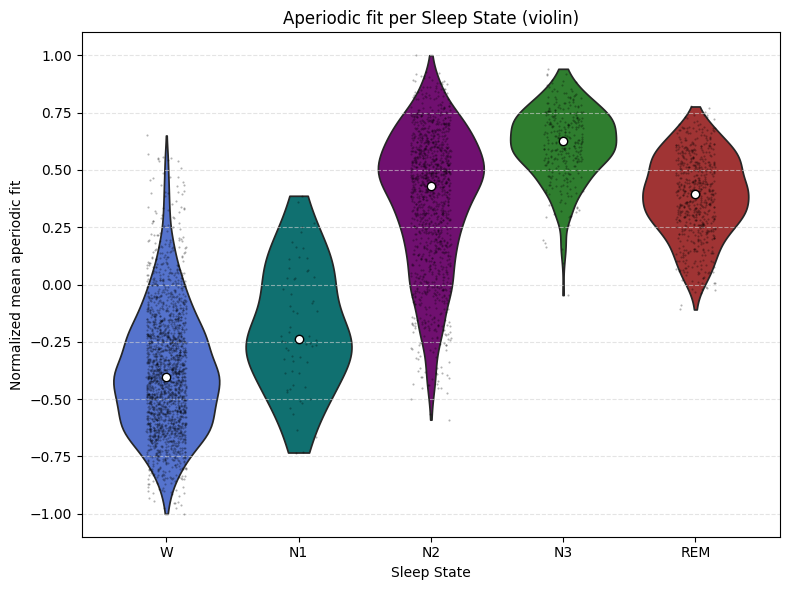

In [20]:
# # Powerband plot
# F.normalised_powers(EMG_norm, noise_norm, delta_norm, theta_norm, sigma_norm, beta_norm, gamma_norm, alpha_norm, hypno_epochs, sleep_scoring, output_dir)
# # Normalised EMG
# F.normalised_EMG(EMG_norm, output_dir)
# # Raw signals
# F.raw_signals(states, raw_hpc, raw_pfc, pfc_tag, hpc_tag, output_dir)
# # Indices vs a hypnogram
# F.indices_vs_hypnogram(epochs, hypno_epochs, index_w, index_n, index_r, mapped_scores, output_dir)
# # Index barplot
# F.index_barplot(index_n, index_r, index_w, mapped_scores, output_dir)
# # index PCA
# F.index_pca(index_n, mapped_scores, index_r, index_w, output_dir)
# Aperiodic fit
normalized_exponents, smoothed_exponents, valid_states, aperiodic_exponents = F.aperiodic_fit(pfc_data, states, fs, raw_pfc, output_dir)
# Fractal power component
eeg_in_epochs, mean_raw_slope_by_state, mean_smoothed_slope_by_state = F.fractal_power_component(states, subject, raw_pfc, output_dir)
# Slope per state
smoothed_slopes = F.slope_per_state(output_dir, mean_raw_slope_by_state, mean_smoothed_slope_by_state,
                    states, eeg_in_epochs)
# Fractal slope vs hypnogram
F.fractal_slope_vs_hypnogram(subject, smoothed_slopes, output_dir, states)
# FOOOf report
F.fooof_report(output_dir, raw_pfc)
# Aperiodic fit bar plot
F.aperiodic_fit_bar(valid_states, normalized_exponents, output_dir)
# Aperiodic fit violin plot
F.aperiodic_fit_violin(valid_states, normalized_exponents, output_dir)